# TT-06 — Naive Bayes: Lọc tin nhắn rác cho tổng đài viễn thông


## Import thư viện

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import os

os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Nạp dữ liệu, kiểm tra encoding

In [5]:
import pandas as pd

DATA_PATH = "D:\TT_ML\TT-06-NaiveBayes_Linh\dataset\spam.csv"

df = pd.read_csv(DATA_PATH, encoding="latin-1")

# Chỉ lấy 2 cột cần thiết
df = df.iloc[:, :2]
df.columns = ["label", "text"]
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(4) * 100 ) # tỉ lệ %
print(df.shape)
print(df.head())

label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64
(5572, 2)
  label  \
0   ham   
1   ham   
2  spam   
3   ham   
4   ham   

                                                                                                                      text  
0          Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...  
1                                                                                            Ok lar... Joking wif u oni...  
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std t...  
3                                                                        U dun say so early hor... U c already then say...  
4                                                            Nah I don't think he goes to usf, he lives around here though  


<>:3: SyntaxWarning: invalid escape sequence '\T'
<>:3: SyntaxWarning: invalid escape sequence '\T'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_19360\88156406.py:3: SyntaxWarning: invalid escape sequence '\T'
  DATA_PATH = "D:\TT_ML\TT-06-NaiveBayes_Linh\dataset\spam.csv"


## 2. Kiểm tra & loại tin nhắn trùng lặp

In [6]:
n_dup = df.duplicated().sum()
print(f"Số dòng trùng lặp: {n_dup} / {len(df)} ({n_dup/len(df)*100:.1f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Sau khi loại trùng: {df.shape}")

Số dòng trùng lặp: 403 / 5572 (7.2%)
Sau khi loại trùng: (5169, 2)


## 3. EDA: độ dài tin nhắn ham vs spam

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
spam,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


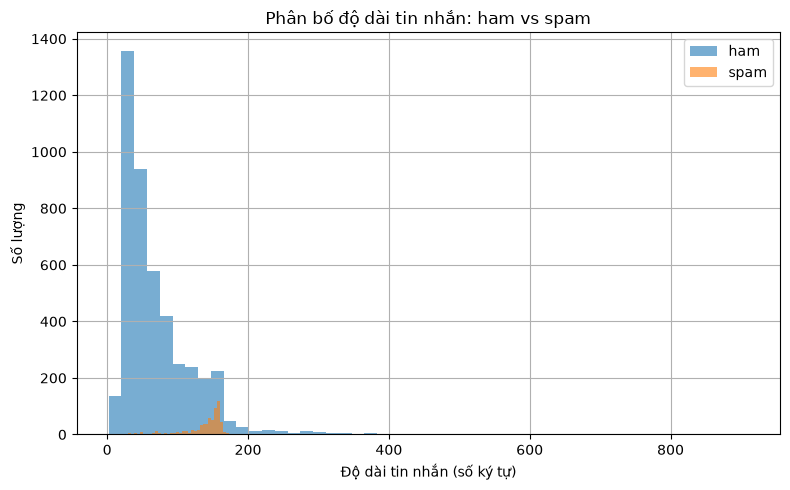

In [7]:
df["length"] = df["text"].str.len()
display(df.groupby("label")["length"].describe())

fig, ax = plt.subplots()
df[df.label == "ham"]["length"].hist(bins=50, alpha=0.6, label="ham", ax=ax)
df[df.label == "spam"]["length"].hist(bins=50, alpha=0.6, label="spam", ax=ax)
ax.set_xlabel("Độ dài tin nhắn (số ký tự)")
ax.set_ylabel("Số lượng")
ax.set_title("Phân bố độ dài tin nhắn: ham vs spam")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/do_dai_tin.png", dpi=120)
plt.show()

## 4. Chia train/test & Baseline

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"Baseline (đoán 'ham' hết) — accuracy: {dummy_acc:.4f}  <-- cao nhưng vô dụng")

Train: 4135 | Test: 1034
Baseline (đoán 'ham' hết) — accuracy: 0.8733  <-- cao nhưng vô dụng


## 5-7. So sánh 3 tổ hợp

In [9]:
configs = {
    "Count + Multinomial": make_pipeline(
        CountVectorizer(lowercase=True), MultinomialNB()
    ),
    "TFIDF + Multinomial": make_pipeline(
        TfidfVectorizer(lowercase=True, sublinear_tf=True), MultinomialNB()
    ),
    "TFIDF + Bernoulli": make_pipeline(
        TfidfVectorizer(lowercase=True, sublinear_tf=True), BernoulliNB()
    ),
}

results = []
fitted_pipes = {}

for name, pipe in configs.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "precision": precision_score(y_test, y_pred, pos_label="spam"),
        "recall": recall_score(y_test, y_pred, pos_label="spam"),
        "f1": f1_score(y_test, y_pred, pos_label="spam"),
    })
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
results_df

,model,precision,recall,f1
0,Count + Multinomial,0.975610,0.916031,0.944882
2,TFIDF + Bernoulli,0.990741,0.816794,0.895397
1,TFIDF + Multinomial,1.000000,0.633588,0.775701


## 8. Dò alpha và ngram_range

In [10]:
pipe_grid = make_pipeline(
    TfidfVectorizer(lowercase=True, min_df=2, max_df=0.9, sublinear_tf=True),
    MultinomialNB(),
)

param_grid = {
    "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
    "multinomialnb__alpha": [0.01, 0.1, 0.5, 1.0],
}

grid = GridSearchCV(pipe_grid, param_grid, scoring="f1_weighted", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV f1_weighted: {grid.best_score_:.4f}")

best_pipe = grid.best_estimator_
y_pred_best = best_pipe.predict(X_test)
print()
print(classification_report(y_test, y_pred_best, digits=4))

Best params: {'multinomialnb__alpha': 0.01, 'tfidfvectorizer__ngram_range': (1, 1)}
Best CV f1_weighted: 0.9847

              precision    recall  f1-score   support

         ham     0.9825    0.9967    0.9896       903
        spam     0.9746    0.8779    0.9237       131

    accuracy                         0.9816      1034
   macro avg     0.9786    0.9373    0.9566      1034
weighted avg     0.9815    0.9816    0.9812      1034



In [11]:
cv_results = pd.DataFrame(grid.cv_results_)[
    ["param_tfidfvectorizer__ngram_range", "param_multinomialnb__alpha", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
cv_results.columns = ["ngram_range", "alpha", "mean_f1_weighted", "std"]
cv_results.reset_index(drop=True)

,ngram_range,alpha,mean_f1_weighted,std
0,"(1, 1)",0.01,0.984715,0.002691
1,"(1, 2)",0.10,0.984189,0.002697
2,"(1, 1)",0.10,0.983922,0.004009
3,"(1, 2)",0.01,0.983516,0.004192
4,"(1, 1)",0.50,0.978901,0.006361
5,"(1, 2)",0.50,0.973618,0.004484
6,"(1, 1)",1.00,0.966252,0.007071
7,"(1, 2)",1.00,0.958116,0.006899


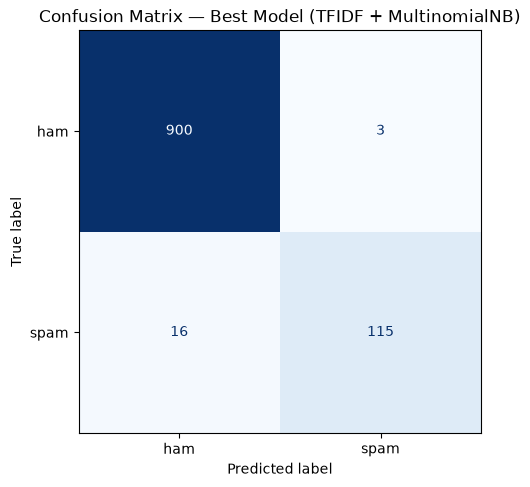

In [24]:
cm = confusion_matrix(y_test, y_pred_best, labels=["ham", "spam"])
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Best Model (TFIDF + MultinomialNB)")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=120)
plt.show()

## 9. Top 20 từ có xác suất cao nhất cho lớp spam


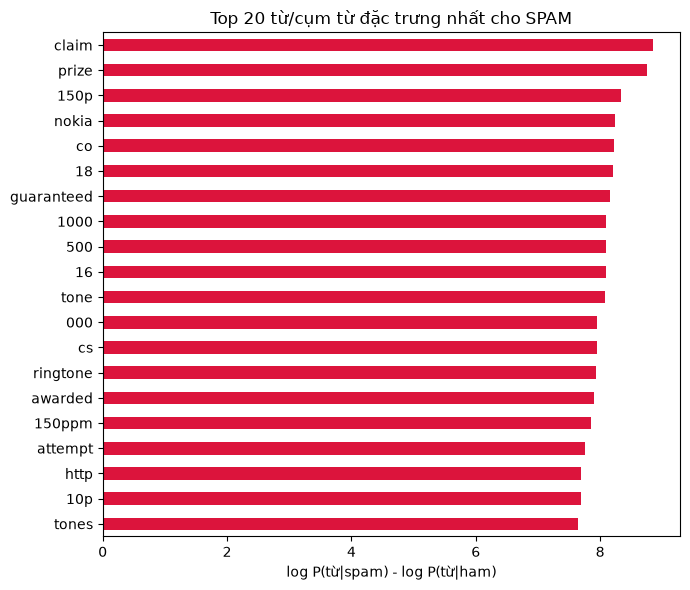

,từ/cụm từ,log_ratio
0,claim,8.842098
1,prize,8.759717
2,150p,8.336677
3,nokia,8.246839
4,co,8.219307
5,18,8.204340
6,guaranteed,8.155428
7,1000,8.094930
8,500,8.094290
9,16,8.087194


In [13]:
vectorizer = best_pipe.named_steps["tfidfvectorizer"]
nb_model = best_pipe.named_steps["multinomialnb"]

feature_names = vectorizer.get_feature_names_out()
spam_idx = list(nb_model.classes_).index("spam")
ham_idx = list(nb_model.classes_).index("ham")

log_ratio = nb_model.feature_log_prob_[spam_idx] - nb_model.feature_log_prob_[ham_idx]
top20_spam = pd.Series(log_ratio, index=feature_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
top20_spam.sort_values().plot(kind="barh", ax=ax, color="crimson")
ax.set_xlabel("log P(từ|spam) - log P(từ|ham)")
ax.set_title("Top 20 từ/cụm từ đặc trưng nhất cho SPAM")
plt.tight_layout()
plt.savefig("../reports/top_tu_spam.png", dpi=120)
plt.show()

top20_spam.reset_index().rename(columns={"index": "từ/cụm từ", 0: "log_ratio"})

## 10. Chọn ngưỡng để đạt precision ≥ 0.98

In [15]:
y_proba = best_pipe.predict_proba(X_test)[:, spam_idx]
y_test_bin = (y_test == "spam").astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_test_bin, y_proba)

TARGET_PRECISION = 0.98
# precision_recall_curve trả về precisions có độ dài = len(thresholds)+1, bỏ phần tử cuối để khớp
valid_idx = np.where(precisions[:-1] >= TARGET_PRECISION)[0]

if len(valid_idx) > 0:
    idx = valid_idx[0]  # ngưỡng thấp nhất đạt được precision mục tiêu -> recall cao nhất có thể
    chosen_threshold = thresholds[idx]
    achieved_precision = precisions[idx]
    achieved_recall = recalls[idx]
    print(f"Ngưỡng chọn: {chosen_threshold:.4f}")
    print(f"Precision đạt được: {achieved_precision:.4f}")
    print(f"Recall tương ứng:   {achieved_recall:.4f}")
else:
    print(f"Không tìm được ngưỡng nào đạt precision >= {TARGET_PRECISION} trên tập test này.")
    chosen_threshold = 0.5
y_pred_thresh = np.where(y_proba >= chosen_threshold, "spam", "ham")

print(f"=== Kết quả sau khi chỉnh ngưỡng ({chosen_threshold:.4f}) ===")
print(classification_report(y_test, y_pred_thresh, digits=4))

Ngưỡng chọn: 0.5710
Precision đạt được: 0.9829
Recall tương ứng:   0.8779
=== Kết quả sau khi chỉnh ngưỡng (0.5710) ===
              precision    recall  f1-score   support

         ham     0.9826    0.9978    0.9901       903
        spam     0.9829    0.8779    0.9274       131

    accuracy                         0.9826      1034
   macro avg     0.9827    0.9378    0.9588      1034
weighted avg     0.9826    0.9826    0.9822      1034



## 11. In ra 10 tin bị phân loại sai

In [16]:
y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

wrong_mask = y_pred_thresh != y_test_reset.values
errors_df = pd.DataFrame({
    "text": X_test_reset[wrong_mask],
    "actual": y_test_reset[wrong_mask].values,
    "predicted": y_pred_thresh[wrong_mask],
    "proba_spam": y_proba[wrong_mask],
}).reset_index(drop=True)

print(f"Tổng số ca sai: {len(errors_df)} / {len(y_test)}")
errors_df.head(10)

Tổng số ca sai: 18 / 1034


,text,actual,predicted,proba_spam
0,K:)eng rocking in ashes:),ham,spam,0.946793
1,Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING...,spam,ham,0.057838
2,Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 J...,spam,ham,0.025783
3,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT....,spam,ham,0.458909
4,Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 0909972639...,spam,ham,0.116243
5,Missed call alert. These numbers called but left no message. 07008009200,spam,ham,0.081666
6,SMS. ac sun0819 posts HELLO:\You seem cool,spam,ham,0.332594
7,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about ...,spam,ham,0.004179
8,Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo,spam,ham,0.304289
9,88066 FROM 88066 LOST 3POUND HELP,spam,ham,0.235151


## 12. So sánh với Logistic Regression + TF-IDF

In [17]:
logreg_pipe = make_pipeline(
    TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.9),
    LogisticRegression(max_iter=1000),
)

t0 = time.perf_counter()
logreg_pipe.fit(X_train, y_train)
logreg_train_time = time.perf_counter() - t0

y_pred_lr = logreg_pipe.predict(X_test)

print(f"Thời gian train Logistic Regression: {logreg_train_time*1000:.1f} ms")
print()
print(classification_report(y_test, y_pred_lr, digits=4))
comparison = pd.DataFrame([
    {
        "model": "Naive Bayes (best, threshold-tuned)",
        "precision": precision_score(y_test, y_pred_thresh, pos_label="spam"),
        "recall": recall_score(y_test, y_pred_thresh, pos_label="spam"),
        "f1": f1_score(y_test, y_pred_thresh, pos_label="spam"),
    },
    {
        "model": "Naive Bayes (best, default 0.5)",
        "precision": precision_score(y_test, y_pred_best, pos_label="spam"),
        "recall": recall_score(y_test, y_pred_best, pos_label="spam"),
        "f1": f1_score(y_test, y_pred_best, pos_label="spam"),
    },
    {
        "model": "Logistic Regression + TFIDF",
        "precision": precision_score(y_test, y_pred_lr, pos_label="spam"),
        "recall": recall_score(y_test, y_pred_lr, pos_label="spam"),
        "f1": f1_score(y_test, y_pred_lr, pos_label="spam"),
    },
])
comparison

Thời gian train Logistic Regression: 165.0 ms

              precision    recall  f1-score   support

         ham     0.9596    0.9989    0.9788       903
        spam     0.9894    0.7099    0.8267       131

    accuracy                         0.9623      1034
   macro avg     0.9745    0.8544    0.9028      1034
weighted avg     0.9633    0.9623    0.9596      1034



,model,precision,recall,f1
0,"Naive Bayes (best, threshold-tuned)",0.982906,0.877863,0.927419
1,"Naive Bayes (best, default 0.5)",0.974576,0.877863,0.923695
2,Logistic Regression + TFIDF,0.989362,0.709924,0.826667


## 13. Đo thời gian train , thời gian dự đoán 1 tin

In [18]:
t0 = time.perf_counter()
final_pipe = make_pipeline(
    TfidfVectorizer(**{k.split("__")[1]: v for k, v in grid.best_params_.items() if k.startswith("tfidfvectorizer")},
                     min_df=2, max_df=0.9, sublinear_tf=True),
    MultinomialNB(**{k.split("__")[1]: v for k, v in grid.best_params_.items() if k.startswith("multinomialnb")}),
)
final_pipe.fit(X_train, y_train)
train_time = time.perf_counter() - t0
print(f"Thời gian train trên {len(X_train)} tin: {train_time:.3f} giây")

sample = X_test.iloc[[0]]
# warm-up
final_pipe.predict(sample)

n_runs = 100
t0 = time.perf_counter()
for _ in range(n_runs):
    final_pipe.predict(sample)
avg_ms = (time.perf_counter() - t0) / n_runs * 1000
print(f"Thời gian dự đoán trung bình 1 tin (qua {n_runs} lần): {avg_ms:.3f} ms")
print("Đạt yêu cầu < 5ms/tin!" if avg_ms < 5 else "CHƯA đạt yêu cầu < 5ms/tin, cần tối ưu thêm.")

Thời gian train trên 4135 tin: 0.058 giây
Thời gian dự đoán trung bình 1 tin (qua 100 lần): 0.469 ms
Đạt yêu cầu < 5ms/tin!


## 14. Lưu model

In [19]:
MODEL_PATH = "../models/nb_pipeline.joblib"
joblib.dump(final_pipe, MODEL_PATH)
print(f"Đã lưu model vào {MODEL_PATH}")

# Lưu kèm ngưỡng đã chọn để dùng lúc inference
threshold_info = {"threshold": float(chosen_threshold), "positive_class": "spam"}
import json
with open("../models/threshold.json", "w", encoding="utf-8") as f:
    json.dump(threshold_info, f, ensure_ascii=False, indent=2)
print(f"Đã lưu ngưỡng: {threshold_info}")

Đã lưu model vào ../models/nb_pipeline.joblib
Đã lưu ngưỡng: {'threshold': 0.5709715130593095, 'positive_class': 'spam'}
